# TabPFN v3 walk-forward: saved-results viewer

This notebook **does not train or fit TabPFN**. It reads prediction checkpoints produced by the walk-forward notebook, displays the saved runs, and rebuilds the regression/betting tables and diagnostic plots.

Run the cells from top to bottom. Change `EXPERIMENT_NAME` if the artifacts are in another folder.

In [4]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# The training notebook currently writes to this folder. Change it to, for
# example, 'tabpfn_v3_walk_forward_2_3' when viewing a differently named run.
DRIVE_PROJECT_DIR = Path('/content/drive/MyDrive/NBA_over_under_predictor')
EXPERIMENT_NAME = 'tabpfn_v3_walk_forward_2_3_all_features'
ARTIFACT_DIR = DRIVE_PROJECT_DIR / 'artifacts' / EXPERIMENT_NAME

TARGETS_TO_PLOT = ('line_error', 'total_points', 'spread_error')
EDGE_THRESHOLDS = (0.0, 0.25, 0.50, 0.75, 1.0, 1.25, 1.50, 1.75, 2.0)
PLOT_EDGE_THRESHOLDS = (0.0, 0.50, 1.0, 1.50, 2.0)
PRIMARY_EDGE = 2.0

# Optionally pin an exact saved configuration after inspecting the next cell.
# None selects the checkpoint with the most games, then the newest one.
RUN_FINGERPRINTS = {
    'line_error': None,
    'total_points': None,
    'spread_error': None,
}

if Path('/content').exists():
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

if not ARTIFACT_DIR.exists():
    raise FileNotFoundError(
        f'Artifact folder not found: {ARTIFACT_DIR}\n'
        'Check EXPERIMENT_NAME and confirm Google Drive is mounted.'
    )
print('Reading saved results from:', ARTIFACT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reading saved results from: /content/drive/MyDrive/NBA_over_under_predictor/artifacts/tabpfn_v3_walk_forward_2_3_all_features


## Discover saved runs

A fingerprint identifies the dataset and training configuration used by the original experiment. This cell only reads checkpoint metadata and predictions; it never imports TabPFN.

In [5]:
CHECKPOINT_PATTERN = re.compile(
    r'^(line_error|total_points|spread_error)_([0-9a-f]+)_predictions\.csv$'
)
REQUIRED_COLUMNS = {
    'GAME_ID', 'GAME_DATE', 'y_true', 'y_pred', 'actual_outcome',
    'market_line', 'predicted_edge', 'actual_edge',
    'positive_price', 'negative_price',
}

def discover_checkpoints(artifact_dir: Path) -> pd.DataFrame:
    records = []
    for checkpoint in artifact_dir.glob('*_predictions.csv'):
        match = CHECKPOINT_PATTERN.match(checkpoint.name)
        if not match:
            continue
        target, fingerprint = match.groups()
        preview = pd.read_csv(
            checkpoint, usecols=lambda column: column in {'GAME_ID', 'GAME_DATE'}
        )
        dates = pd.to_datetime(preview['GAME_DATE'], errors='coerce')
        metadata_path = artifact_dir / f'{target}_{fingerprint}_metadata.json'
        metadata = {}
        if metadata_path.exists():
            metadata = json.loads(metadata_path.read_text())
        records.append({
            'target': target,
            'fingerprint': fingerprint,
            'games': len(preview),
            'game_dates': dates.nunique(),
            'start': dates.min().date() if dates.notna().any() else pd.NaT,
            'end': dates.max().date() if dates.notna().any() else pd.NaT,
            'train_games': metadata.get('train_games'),
            'features': metadata.get('n_features'),
            'estimators': metadata.get('n_estimators'),
            'model': metadata.get('tabpfn_model'),
            'modified': pd.Timestamp(checkpoint.stat().st_mtime, unit='s'),
            'path': checkpoint,
        })
    if not records:
        raise FileNotFoundError(f'No prediction checkpoints found in {artifact_dir}')
    return (
        pd.DataFrame(records)
        .sort_values(['target', 'games', 'modified'], ascending=[True, False, False])
        .reset_index(drop=True)
    )

available_runs = discover_checkpoints(ARTIFACT_DIR)
display(available_runs.drop(columns='path'))

,target,fingerprint,games,game_dates,start,end,train_games,features,estimators,model,modified
0,line_error,7d70ab1d2d221600,610,81,2026-01-18,2026-04-17,6500,1593,8,v3,2026-09-14 16:36:42
1,total_points,6e81f11321c31880,97,13,2026-01-18,2026-01-30,6500,1593,8,v3,2026-09-14 16:44:33


## Load one checkpoint per target

Set a value in `RUN_FINGERPRINTS` above to compare a particular configuration. Otherwise, selection favors the checkpoint containing the most games.

In [6]:
def load_target_checkpoint(target: str) -> tuple[pd.DataFrame, pd.Series]:
    candidates = available_runs.loc[available_runs['target'] == target]
    if candidates.empty:
        raise FileNotFoundError(f'No saved checkpoint found for {target!r}.')

    requested_fingerprint = RUN_FINGERPRINTS.get(target)
    if requested_fingerprint is not None:
        candidates = candidates.loc[
            candidates['fingerprint'] == requested_fingerprint
        ]
        if candidates.empty:
            raise ValueError(
                f'Fingerprint {requested_fingerprint!r} was not found for {target!r}.'
            )

    selected = candidates.sort_values(
        ['games', 'modified'], ascending=[False, False]
    ).iloc[0]
    predictions = pd.read_csv(
        selected['path'], parse_dates=['GAME_DATE'], dtype={'GAME_ID': str}
    )
    missing = sorted(REQUIRED_COLUMNS - set(predictions.columns))
    if missing:
        raise ValueError(f"{selected['path'].name} is missing columns: {missing}")
    predictions = (
        predictions.drop_duplicates(['GAME_ID', 'GAME_DATE'], keep='last')
        .sort_values(['GAME_DATE', 'GAME_ID'])
        .reset_index(drop=True)
    )
    return predictions, selected

predictions_by_target = {}
selected_records = []
for target in TARGETS_TO_PLOT:
    try:
        predictions, selected = load_target_checkpoint(target)
    except FileNotFoundError as error:
        print(f'Skipping {target}: {error}')
        continue
    predictions_by_target[target] = predictions
    selected_records.append(selected.drop(labels='path').to_dict())

if not predictions_by_target:
    raise FileNotFoundError('None of TARGETS_TO_PLOT has a saved checkpoint.')

print('Selected saved runs (no models were fitted):')
display(pd.DataFrame(selected_records))

Skipping spread_error: No saved checkpoint found for 'spread_error'.
Selected saved runs (no models were fitted):


,target,fingerprint,games,game_dates,start,end,train_games,features,estimators,model,modified
0,line_error,7d70ab1d2d221600,610,81,2026-01-18,2026-04-17,6500,1593,8,v3,2026-09-14 16:36:42
1,total_points,6e81f11321c31880,97,13,2026-01-18,2026-01-30,6500,1593,8,v3,2026-09-14 16:44:33


## Recalculate result tables

In [7]:
def wilson_interval(
    wins: int, trials: int, z: float = 1.959963984540054
) -> tuple[float, float]:
    if trials == 0:
        return np.nan, np.nan
    p = wins / trials
    denominator = 1.0 + z**2 / trials
    center = (p + z**2 / (2.0 * trials)) / denominator
    margin = z / denominator * np.sqrt(
        p * (1.0 - p) / trials + z**2 / (4.0 * trials**2)
    )
    return float(center - margin), float(center + margin)

def regression_summary(predictions: pd.DataFrame, target: str) -> dict:
    y_true = predictions['y_true'].to_numpy(dtype=float)
    y_pred = predictions['y_pred'].to_numpy(dtype=float)
    baseline = (
        predictions['market_line'].to_numpy(dtype=float)
        if target == 'total_points'
        else np.zeros(len(predictions))
    )
    return {
        'target': target,
        'games': len(predictions),
        'game_dates': predictions['GAME_DATE'].nunique(),
        'start': predictions['GAME_DATE'].min().date(),
        'end': predictions['GAME_DATE'].max().date(),
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': mean_squared_error(y_true, y_pred) ** 0.5,
        'r2': r2_score(y_true, y_pred),
        'baseline_mae': mean_absolute_error(y_true, baseline),
    }

def evaluate_threshold(predictions: pd.DataFrame, threshold: float) -> dict:
    edge = predictions['predicted_edge'].to_numpy(dtype=float)
    actual = predictions['actual_edge'].to_numpy(dtype=float)
    placed = np.isfinite(edge) & np.isfinite(actual) & (np.abs(edge) > threshold)
    positive_bet = edge[placed] > 0
    realised = actual[placed]
    positive_price = predictions['positive_price'].to_numpy(dtype=float)[placed]
    negative_price = predictions['negative_price'].to_numpy(dtype=float)[placed]
    price = np.where(positive_bet, positive_price, negative_price)
    push = realised == 0
    won = np.where(positive_bet, realised > 0, realised < 0) & ~push
    lost = ~won & ~push
    n_bets = int(placed.sum())
    n_wins = int(won.sum())
    n_losses = int(lost.sum())
    n_pushes = int(push.sum())
    n_decided = n_wins + n_losses
    win_rate = n_wins / n_decided if n_decided else np.nan
    ci_low, ci_high = wilson_interval(n_wins, n_decided)
    profit = float(np.sum(price[won] - 1.0) - n_losses)
    return {
        'min_edge': threshold,
        'n_bets': n_bets,
        'bet_rate': n_bets / len(predictions),
        'wins': n_wins,
        'losses': n_losses,
        'pushes': n_pushes,
        'win_rate': win_rate,
        'ci_low': ci_low,
        'ci_high': ci_high,
        'break_even': float(np.mean(1.0 / price)) if n_bets else np.nan,
        'profit_units': profit,
        'roi': profit / n_bets if n_bets else np.nan,
    }

regression_results = pd.DataFrame([
    regression_summary(predictions, target)
    for target, predictions in predictions_by_target.items()
]).set_index('target')
betting_results = pd.concat(
    {
        target: pd.DataFrame([
            evaluate_threshold(predictions, threshold)
            for threshold in EDGE_THRESHOLDS
        ])
        for target, predictions in predictions_by_target.items()
    },
    names=['target', 'row'],
).reset_index(level='row', drop=True)

display(regression_results.round(4))
display(betting_results.round(4))

,games,game_dates,start,end,mae,rmse,r2,baseline_mae
target,,,,,,,,
line_error,610,81,2026-01-18,2026-04-17,14.3848,18.2414,0.0016,14.4074
total_points,97,13,2026-01-18,2026-01-30,14.7816,19.1717,0.0352,14.7887


,min_edge,n_bets,bet_rate,wins,losses,pushes,win_rate,ci_low,ci_high,break_even,profit_units,roi
target,,,,,,,,,,,,
line_error,0.00,610,1.0000,310,289,11,0.5175,0.4775,0.5573,0.5238,-7.1818,-0.0118
line_error,0.25,450,0.7377,235,210,5,0.5281,0.4817,0.5740,0.5238,3.6364,0.0081
line_error,0.50,300,0.4918,148,148,4,0.5000,0.4434,0.5566,0.5238,-13.4545,-0.0448
line_error,0.75,151,0.2475,77,70,4,0.5238,0.4435,0.6029,0.5238,-0.0000,-0.0000
line_error,1.00,72,0.1180,42,29,1,0.5915,0.4754,0.6983,0.5238,9.1818,0.1275
line_error,1.25,28,0.0459,18,10,0,0.6429,0.4583,0.7929,0.5238,6.3636,0.2273
line_error,1.50,9,0.0148,8,1,0,0.8889,0.5650,0.9801,0.5238,6.2727,0.6970
line_error,1.75,2,0.0033,2,0,0,1.0000,0.3424,1.0000,0.5238,1.8182,0.9091
line_error,2.00,1,0.0016,1,0,0,1.0000,0.2065,1.0000,0.5238,0.9091,0.9091


## Per-target diagnostics

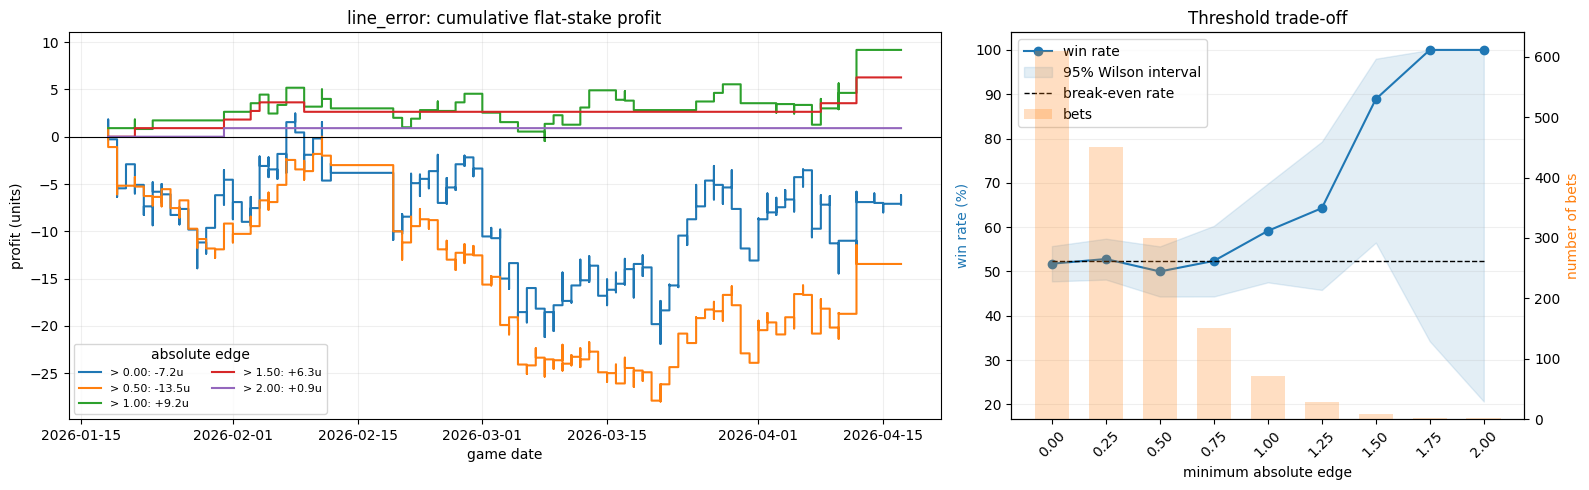

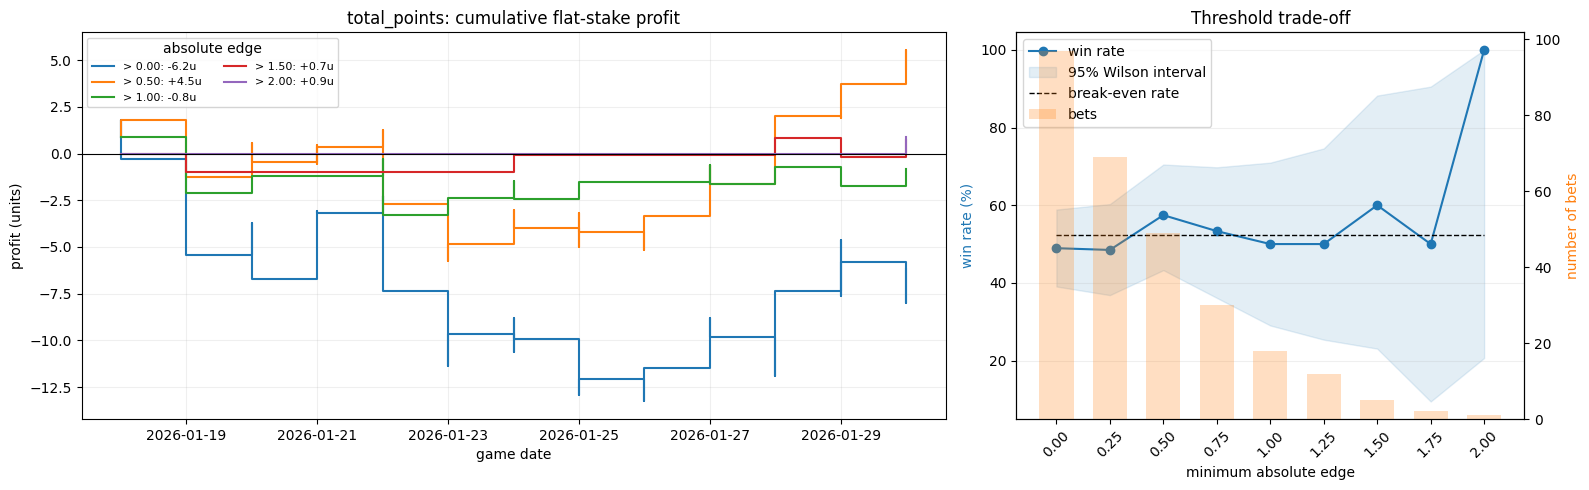

In [8]:
def add_bet_profit(predictions: pd.DataFrame, threshold: float) -> pd.DataFrame:
    out = predictions.sort_values(['GAME_DATE', 'GAME_ID']).copy()
    edge = out['predicted_edge'].to_numpy(dtype=float)
    actual = out['actual_edge'].to_numpy(dtype=float)
    placed = np.isfinite(edge) & np.isfinite(actual) & (np.abs(edge) > threshold)
    push = actual == 0
    won = np.where(edge > 0, actual > 0, actual < 0) & placed & ~push
    lost = placed & ~won & ~push
    price = np.where(edge > 0, out['positive_price'], out['negative_price']).astype(float)
    out['profit'] = np.where(won, price - 1.0, np.where(lost, -1.0, 0.0))
    out['cumulative_profit'] = out['profit'].cumsum()
    return out

def plot_target(target: str, predictions: pd.DataFrame) -> None:
    betting = betting_results.loc[target].reset_index(drop=True)
    fig, (profit_axis, threshold_axis) = plt.subplots(
        1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.7, 1]}
    )
    for threshold in PLOT_EDGE_THRESHOLDS:
        plotted = add_bet_profit(predictions, threshold)
        final_profit = plotted['cumulative_profit'].iloc[-1]
        profit_axis.step(
            plotted['GAME_DATE'], plotted['cumulative_profit'], where='post',
            label=f'> {threshold:.2f}: {final_profit:+.1f}u',
        )
    profit_axis.axhline(0, color='black', linewidth=0.8)
    profit_axis.set_title(f'{target}: cumulative flat-stake profit')
    profit_axis.set_xlabel('game date')
    profit_axis.set_ylabel('profit (units)')
    profit_axis.grid(alpha=0.2)
    profit_axis.legend(title='absolute edge', ncol=2, fontsize=8)

    thresholds = betting['min_edge'].to_numpy(dtype=float)
    threshold_axis.plot(
        thresholds, 100 * betting['win_rate'], color='tab:blue',
        marker='o', label='win rate',
    )
    threshold_axis.fill_between(
        thresholds, 100 * betting['ci_low'], 100 * betting['ci_high'],
        color='tab:blue', alpha=0.12, label='95% Wilson interval',
    )
    threshold_axis.plot(
        thresholds, 100 * betting['break_even'], color='black',
        linestyle='--', linewidth=1.0, label='break-even rate',
    )
    threshold_axis.set_title('Threshold trade-off')
    threshold_axis.set_xlabel('minimum absolute edge')
    threshold_axis.set_ylabel('win rate (%)', color='tab:blue')
    threshold_axis.set_xticks(EDGE_THRESHOLDS)
    threshold_axis.tick_params(axis='x', rotation=45)
    threshold_axis.grid(axis='y', alpha=0.2)
    bet_axis = threshold_axis.twinx()
    bet_axis.bar(
        thresholds, betting['n_bets'], width=0.16, color='tab:orange',
        alpha=0.25, label='bets',
    )
    bet_axis.set_ylabel('number of bets', color='tab:orange')
    left_handles, left_labels = threshold_axis.get_legend_handles_labels()
    right_handles, right_labels = bet_axis.get_legend_handles_labels()
    threshold_axis.legend(
        left_handles + right_handles, left_labels + right_labels, loc='best'
    )
    fig.tight_layout()
    plt.show()

for target, predictions in predictions_by_target.items():
    plot_target(target, predictions)

## Cross-target comparison

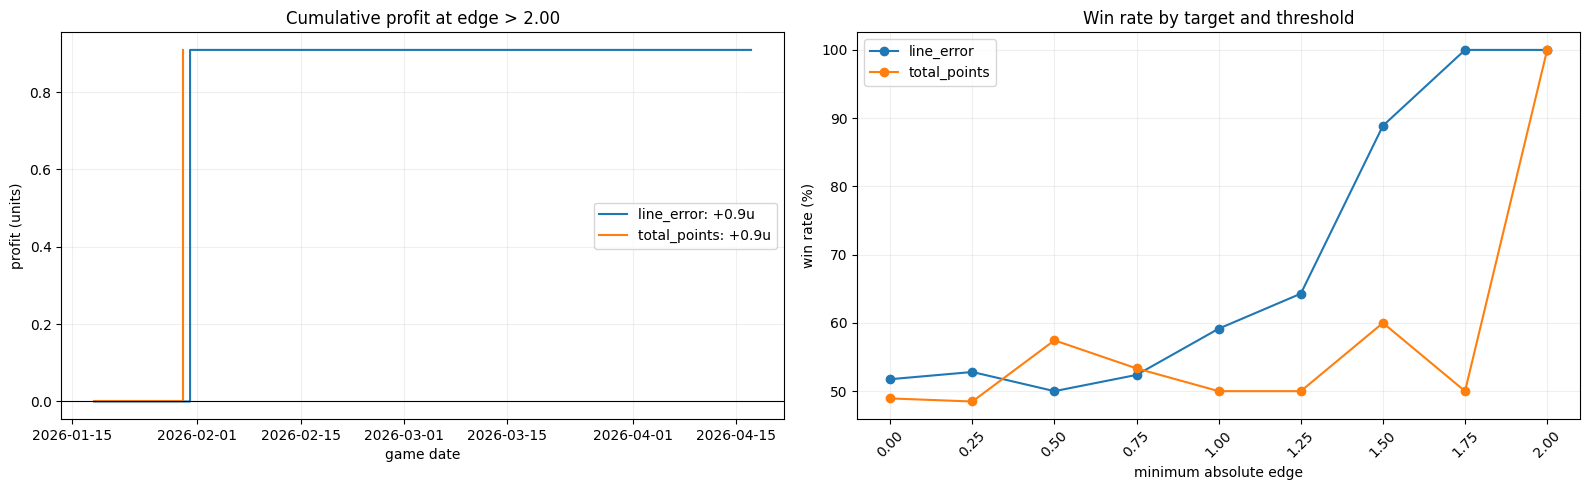

In [9]:
fig, (profit_axis, win_axis) = plt.subplots(1, 2, figsize=(16, 5))
for target, predictions in predictions_by_target.items():
    plotted = add_bet_profit(predictions, PRIMARY_EDGE)
    profit_axis.step(
        plotted['GAME_DATE'], plotted['cumulative_profit'],
        where='post', label=f"{target}: {plotted['cumulative_profit'].iloc[-1]:+.1f}u",
    )
    target_betting = betting_results.loc[target]
    win_axis.plot(
        target_betting['min_edge'], 100 * target_betting['win_rate'],
        marker='o', label=target,
    )

profit_axis.axhline(0, color='black', linewidth=0.8)
profit_axis.set_title(f'Cumulative profit at edge > {PRIMARY_EDGE:.2f}')
profit_axis.set_xlabel('game date')
profit_axis.set_ylabel('profit (units)')
profit_axis.grid(alpha=0.2)
profit_axis.legend()

win_axis.set_title('Win rate by target and threshold')
win_axis.set_xlabel('minimum absolute edge')
win_axis.set_ylabel('win rate (%)')
win_axis.set_xticks(EDGE_THRESHOLDS)
win_axis.tick_params(axis='x', rotation=45)
win_axis.grid(alpha=0.2)
win_axis.legend()
fig.tight_layout()
plt.show()